# Sensor Fusion: From Local Strain to Global Understanding

**Companion notebook to Chapter 58 — Sensor Fusion: From Local Strain to Global Understanding.**

*A single gage sees one point in one direction; the structure only reveals itself when many gages are combined correctly.*

A single strain gage measures strain at one point, in one direction, under one set of thermal and electrical conditions. A network of gages can tell a much richer story — but only if the measurements are combined correctly. **Sensor fusion** is the set of methods for integrating multiple measurements, each with different noise characteristics and potential systematic errors, into a single estimate that is better than any individual measurement.

The most important class for strain measurement is *optimal linear fusion*: weighting each sensor's contribution inversely proportional to its variance, so that more reliable sensors contribute more to the combined result. This is mathematically equivalent to maximum likelihood estimation under Gaussian noise, and it produces a fused estimate whose variance is strictly smaller than any individual input. The improvement follows from the reciprocal-sum rule: two sensors with variances σ₁² and σ₂² fuse to a combined variance σ₁²σ₂²/(σ₁² + σ₂²), always smaller than both.

Temperature complicates fusion by introducing correlated systematic errors. If two sensor arrays operate in different thermal environments, thermal output and gage factor drift introduce biases that noise-weighting cannot remove — even with perfect variance estimates. Thermal corrections must be applied *before* fusion, not after. The correction pipeline is: subtract the apparent strain (thermal output), then divide out the sensitivity drift by multiplying by GF₀/GF(T), and only then apply the optimal weights to the corrected estimates.

**This notebook demonstrates:**
1. Optimal sensor fusion — minimum-variance combination of two load estimates (σ₁ = 300 N, σ₂ = 150 N), compared against a naive simple average
2. Thermal output (apparent strain) — uncompensated Constantan on steel, aluminum, and titanium substrates across −50 °C to +175 °C
3. Gage factor temperature coefficient (TCS) — GF(T) and proportional strain reading error for four alloys
4. Thermally-corrected fusion — RMSE comparison of raw vs. corrected fusion under a 24 → 104 °C temperature gradient

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Figure output directory — these exact paths are what the book \includegraphics
OUT_DIR = Path("../src/media/ch58")
OUT_DIR.mkdir(parents=True, exist_ok=True)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

---
## 1 — Optimal Sensor Fusion: Minimum-Variance Combination

When two sensors estimate the same physical quantity — here, the load on a structure as estimated by two different gage arrays — the optimal way to combine them is to weight each estimate inversely proportional to its variance. This produces the fused estimate with the smallest possible variance, smaller than either sensor alone.

The derivation is straightforward. If Array 1 has noise variance σ₁² and Array 2 has noise variance σ₂², the optimal weights are w₁ = (1/σ₁²)/(1/σ₁² + 1/σ₂²) and w₂ = 1 − w₁. The fused variance is σ_f² = σ₁²σ₂²/(σ₁² + σ₂²) — always less than both σ₁² and σ₂². In this example, Array 1 has σ = 300 N and Array 2 has σ = 150 N; Array 2 is four times more precise in variance terms, so it receives weight w₂ ≈ 0.80. The fused standard deviation is approximately 134 N — better than either sensor alone. For contrast, the figure also plots the naive **simple average** (equal weights): it improves on the worse sensor but is beaten by the variance-weighted fusion, which correctly trusts the more precise array more.

This minimum-variance rule is the foundation of all optimal sensor fusion, from simple weighted averages to full Kalman filters. The key assumption is that the noise on the two sensors is independent (uncorrelated). When this assumption fails — as it does when sensors share a common interference source, or when thermal bias corrupts both readings — the fused result inherits the common error regardless of the weights. The corrections in the sections below address exactly this failure mode.

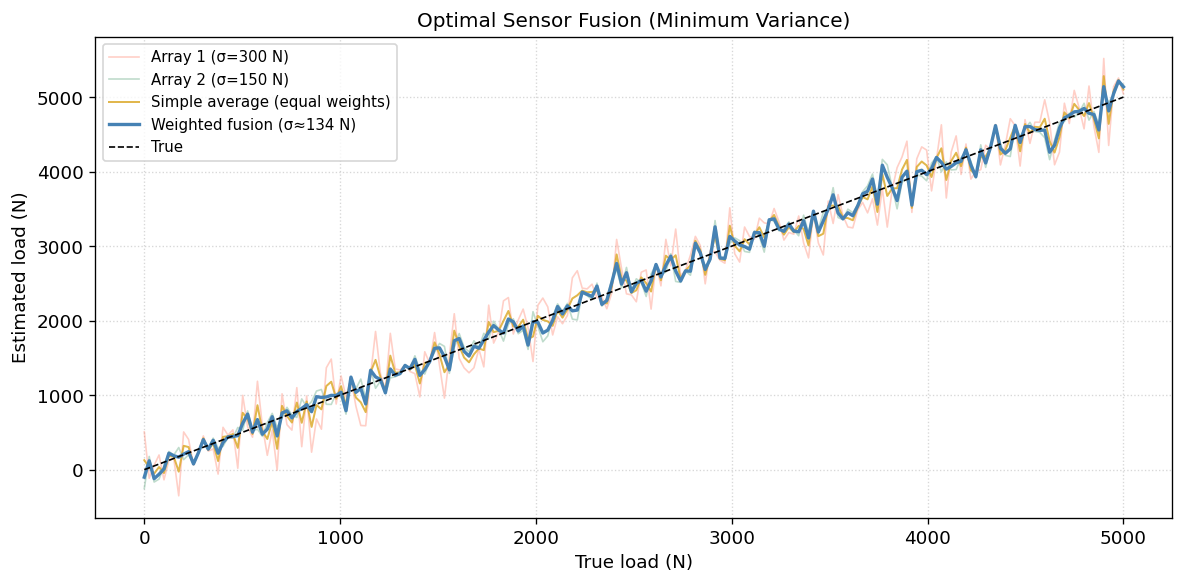

Fusion weights:  w1=0.200  w2=0.800
RMSE  weighted fusion :  131.5 N  (predicted σ≈134 N)
RMSE  simple average  :  164.9 N
RMSE  Array 1 / Array 2: 297.2 N / 147.8 N


In [2]:
# --- Reusable fusion helpers (used here and in the thermal-correction section) ---
def inverse_variance_weights(variances):
    """Minimum-variance fusion weights for independent sensors (Eq. 58.6).

    Each weight is proportional to 1/variance and the weights are normalized to
    sum to 1, so the more precise (lower-variance) sensor counts for more.
    """
    inv = 1.0 / np.asarray(variances, dtype=float)
    return inv / inv.sum()


def fused_variance(variances):
    """Variance of the minimum-variance fusion of independent sensors.

    Follows the reciprocal-sum rule sigma_f^2 = 1 / sum(1/sigma_i^2), which is
    always smaller than the smallest input variance.
    """
    return 1.0 / np.sum(1.0 / np.asarray(variances, dtype=float))


# --- Two independent load estimates from different gage arrays ---
# Each array reports the same true load with independent Gaussian noise; the
# optimal combination weights each inversely to its variance (Eq. 58.6).
SEED = 7
N_SAMPLES = 200
F_MAX_N = 5000.0
SIGMA1_N = 300.0   # Array 1 noise standard deviation (N)
SIGMA2_N = 150.0   # Array 2 noise standard deviation (N) -- 2x more precise

np.random.seed(SEED)
F_true = np.linspace(0, F_MAX_N, N_SAMPLES)
F_est1 = F_true + np.random.normal(0, SIGMA1_N, N_SAMPLES)   # Array 1
F_est2 = F_true + np.random.normal(0, SIGMA2_N, N_SAMPLES)   # Array 2 (more accurate)

# Optimal (minimum-variance) fusion vs. a naive equal-weight average
w1, w2 = inverse_variance_weights([SIGMA1_N**2, SIGMA2_N**2])
F_fused = w1 * F_est1 + w2 * F_est2
F_simple = 0.5 * (F_est1 + F_est2)
sigma_fused = np.sqrt(fused_variance([SIGMA1_N**2, SIGMA2_N**2]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(F_true, F_est1, alpha=0.3, color='tomato', lw=1, label=f'Array 1 (σ={SIGMA1_N:.0f} N)')
ax.plot(F_true, F_est2, alpha=0.3, color='seagreen', lw=1, label=f'Array 2 (σ={SIGMA2_N:.0f} N)')
ax.plot(F_true, F_simple, color='goldenrod', lw=1.2, alpha=0.8, label='Simple average (equal weights)')
ax.plot(F_true, F_fused, color='steelblue', lw=2, label=f'Weighted fusion (σ≈{sigma_fused:.0f} N)')
ax.plot(F_true, F_true, 'k--', lw=1, label='True')
ax.set_xlabel('True load (N)'); ax.set_ylabel('Estimated load (N)')
ax.set_title('Optimal Sensor Fusion (Minimum Variance)'); ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig58_nb1_sensor_fusion_weighted.png', bbox_inches='tight', dpi=150)
plt.show()


def rmse(estimate):
    """Root-mean-square error of an estimate against the known true load."""
    return np.sqrt(np.mean((estimate - F_true)**2))


print(f"Fusion weights:  w1={w1:.3f}  w2={w2:.3f}")
print(f"RMSE  weighted fusion : {rmse(F_fused):6.1f} N  (predicted σ≈{sigma_fused:.0f} N)")
print(f"RMSE  simple average  : {rmse(F_simple):6.1f} N")
print(f"RMSE  Array 1 / Array 2: {rmse(F_est1):.1f} N / {rmse(F_est2):.1f} N")

---
## 2 — Thermal Output (Apparent Strain)

Even with zero mechanical load, a bonded strain gage reports strain when temperature changes. This *apparent strain* arises from two coupled effects:

1. **Differential thermal expansion** — the gage grid and substrate expand at different rates.
2. **Temperature coefficient of resistance (TCR)** — the grid alloy's resistivity changes with temperature.

The direction of the differential term depends on which material expands faster. A substrate with a *higher* expansion coefficient than the grid (aluminum) stretches the bonded grid and drives the apparent strain positive; a *lower*-expansion substrate (titanium) can drive it negative. This is why sensors on different substrates can drift in opposite directions — the systematic error a naive fusion cannot cancel.

Manufacturers offer *self-temperature-compensated* (STC) gages matched to specific substrate materials. A mismatched STC number — or a gage bonded to the wrong alloy — leaves residual apparent strain that corrupts any fusion estimate built on raw bridge output.

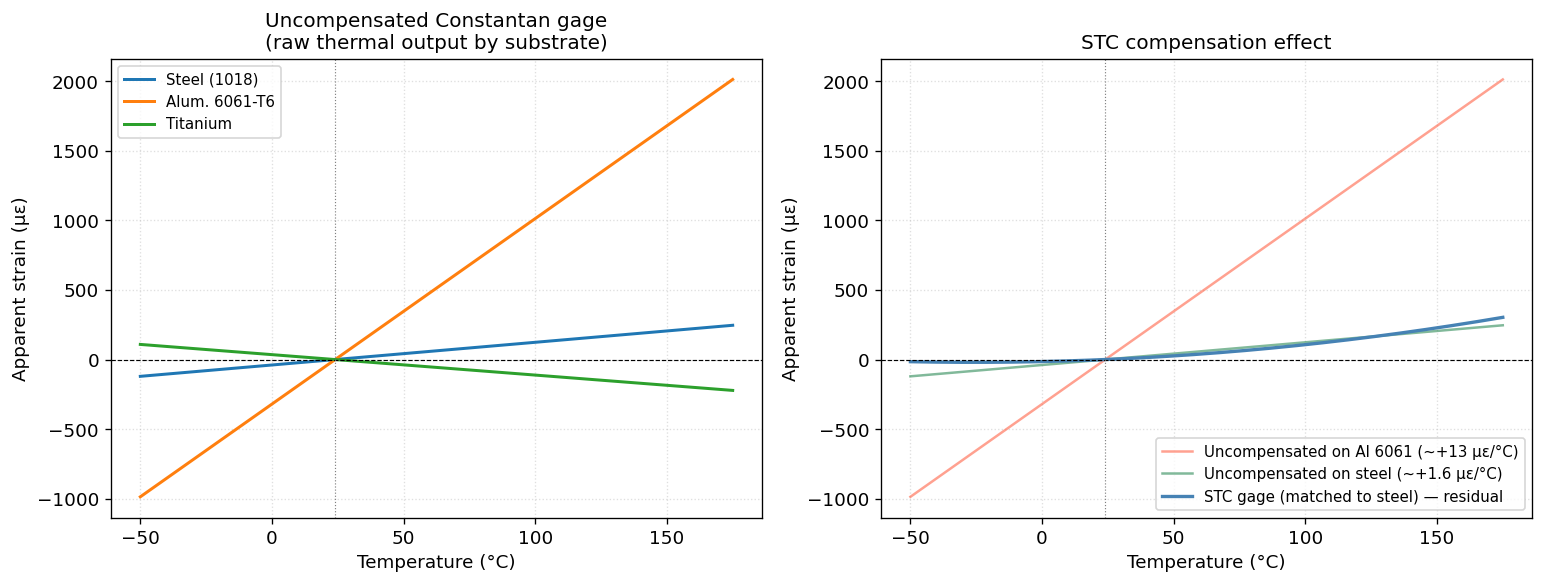

Apparent strain at +100°C above reference:
  Steel (1018)        : +163.1 µε
  Alum. 6061-T6       : +1333.1 µε
  Titanium            : -146.9 µε


In [3]:
# --- Thermal output: apparent strain vs temperature (Constantan grid) ---
# Substrate thermal expansion coefficients (µm/m/°C = ppm/°C)
alpha = {
    'Steel (1018)':   11.7,
    'Alum. 6061-T6':  23.4,
    'Titanium':        8.6,
}

# Constantan grid properties
alpha_grid = 14.9     # ppm/°C  — thermal expansion of Constantan
TCR_grid   = 10.0     # ppm/°C  — temperature coefficient of resistance
GF         = 2.07     # nominal gage factor at 24°C

T_ref = 24.0
T     = np.linspace(-50, 175, 300)
dT    = T - T_ref

def apparent_strain(alpha_s, dT):
    """Thermal output (apparent strain, µε) of a Constantan gage on a substrate.

    Two coupled terms (Micro-Measurements TN-504-1):
      * differential expansion:  (alpha_substrate - alpha_grid) * dT
      * resistivity change:       (TCR_grid / GF) * dT
    A substrate that expands more than the grid (e.g. aluminum) stretches the
    bonded grid, giving a positive differential-expansion contribution.
    """
    eps_mech = (alpha_s - alpha_grid) * dT           # differential expansion (substrate - grid)
    eps_elec = (TCR_grid / GF) * dT                  # resistivity change term
    return eps_mech + eps_elec

# STC gage matched to steel: residual thermal output is small
# Approximate residual as a slight mismatch (real STC curves are polynomial)
stc_steel_residual = 0.8 * dT + 0.008 * dT**2      # µε — typical manufacturer spec

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: raw (uncompensated) Constantan on each substrate
ax = axes[0]
for mat, alpha_s in alpha.items():
    ax.plot(T, apparent_strain(alpha_s, dT), lw=1.8, label=mat)
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.axvline(T_ref, color='gray', lw=0.7, ls=':')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Apparent strain (µε)')
ax.set_title('Uncompensated Constantan gage\n(raw thermal output by substrate)')
ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4)

# Right: STC gage matched to steel — residual vs raw on aluminum and steel
ax = axes[1]
ax.plot(T, apparent_strain(alpha['Alum. 6061-T6'], dT), lw=1.5,
        color='tomato', alpha=0.6, label='Uncompensated on Al 6061 (~+13 µε/°C)')
ax.plot(T, apparent_strain(alpha['Steel (1018)'],  dT), lw=1.5,
        color='seagreen', alpha=0.6, label='Uncompensated on steel (~+1.6 µε/°C)')
ax.plot(T, stc_steel_residual, lw=2.0, color='steelblue',
        label='STC gage (matched to steel) — residual')
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.axvline(T_ref, color='gray', lw=0.7, ls=':')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Apparent strain (µε)')
ax.set_title('STC compensation effect')
ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig58_nb1_thermal_output_uncompensated.png', bbox_inches='tight', dpi=150)
plt.show()

print("Apparent strain at +100°C above reference:")
for mat, alpha_s in alpha.items():
    print(f"  {mat:20s}: {apparent_strain(alpha_s, 100.0):+.1f} µε")

---
## 3 — Gage Factor Temperature Coefficient (TCS)

The gage factor is not constant — it drifts with temperature. The *temperature coefficient of sensitivity* (TCS, or sometimes GTC) quantifies this:

$$GF(T) = GF_0 \left[1 + TCS \cdot (T - T_{ref})\right]$$

If TCS is ignored, the data-reduction equation converts ΔR/R to strain using a GF that is no longer correct, introducing a proportional error in every reading. The effect is small per degree but accumulates over wide temperature excursions common in outdoor or industrial installations.

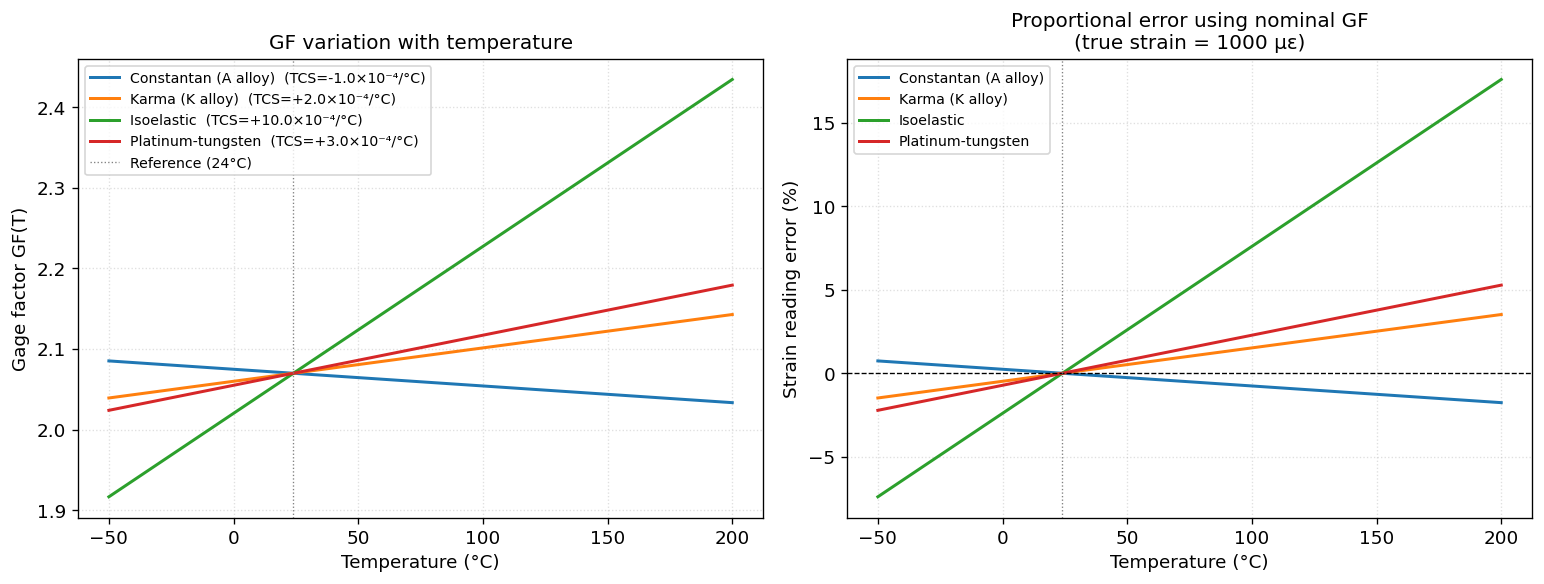

Alloy                          Error at +150°C   Error at −50°C
-----------------------------------------------------------------
Constantan (A alloy)                    -1.26%           +0.74%
Karma (K alloy)                         +2.52%           -1.48%
Isoelastic                             +12.60%           -7.40%
Platinum-tungsten                       +3.78%           -2.22%


In [4]:
# --- Gage factor temperature coefficient (TCS) ---
# Typical TCS values (%/°C → per °C)
gages = {
    'Constantan (A alloy)':  -1.0e-4,   # ≈ −0.010%/°C
    'Karma (K alloy)':       +2.0e-4,   # ≈ +0.020%/°C
    'Isoelastic':            +1.0e-3,   # ≈ +0.100%/°C  (dynamic use only)
    'Platinum-tungsten':     +3.0e-4,   # ≈ +0.030%/°C
}
GF_0 = 2.07
T_ref = 24.0
T = np.linspace(-50, 200, 400)
dT = T - T_ref

# True mechanical strain scenario: 1000 µε at each temperature
eps_true = 1000.0   # µε

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: GF vs temperature for each alloy
ax = axes[0]
for name, tcs in gages.items():
    GF_T = GF_0 * (1 + tcs * dT)
    ax.plot(T, GF_T, lw=1.8, label=f'{name}  (TCS={tcs*1e4:+.1f}×10⁻⁴/°C)')
ax.axvline(T_ref, color='gray', lw=0.8, ls=':', label='Reference (24°C)')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Gage factor GF(T)')
ax.set_title('GF variation with temperature')
ax.legend(fontsize=8.5); ax.grid(True, linestyle=':', alpha=0.4)

# Right: strain reading error if nominal GF is used instead of GF(T)
ax = axes[1]
for name, tcs in gages.items():
    GF_T   = GF_0 * (1 + tcs * dT)
    # Instrument uses nominal GF_0; true signal uses GF(T)
    dR_R   = eps_true * GF_T * 1e-6          # actual bridge output
    eps_indicated = dR_R / (GF_0 * 1e-6)     # what the instrument reports
    error_pct = 100 * (eps_indicated - eps_true) / eps_true
    ax.plot(T, error_pct, lw=1.8, label=name)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(T_ref, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Strain reading error (%)')
ax.set_title(f'Proportional error using nominal GF\n(true strain = {eps_true:.0f} µε)')
ax.legend(fontsize=8.5); ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig58_nb1_gf_temperature_drift.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"{'Alloy':28s}  {'Error at +150°C':>16}  {'Error at −50°C':>15}")
print('-' * 65)
for name, tcs in gages.items():
    e_hot  = 100 * tcs * (150 - T_ref)
    e_cold = 100 * tcs * (-50 - T_ref)
    print(f"{name:28s}  {e_hot:+15.2f}%  {e_cold:+14.2f}%")


---
## 4 — Thermally-Corrected Sensor Fusion

In practice, sensor arrays operate across a temperature gradient. Array 1 may sit near a heat source while Array 2 is in ambient air. If thermal corrections are not applied *before* fusion, the weighted average inherits a systematic bias that noise-weighting cannot remove — even with perfect variance estimates.

The correction pipeline:
1. Subtract the apparent strain (thermal output) using the measured temperature and the gage's thermal-output coefficient.
2. Divide out the sensitivity drift by multiplying by `GF₀/GF(T)` (the inverse of the gage-factor ratio).
3. *Then* fuse the corrected estimates with optimal weights.

How much this buys depends on the scenario. Here the hot, biased array is also the noisier one, so the variance weighting already leans on the cooler, cleaner array — the correction still helps, but the size of the gain is scenario-dependent. It grows sharply when the biased sensors carry more weight, or when several arrays share the *same* thermal environment: a **correlated** bias that averaging cannot remove at all (the failure mode of Chapter 48).

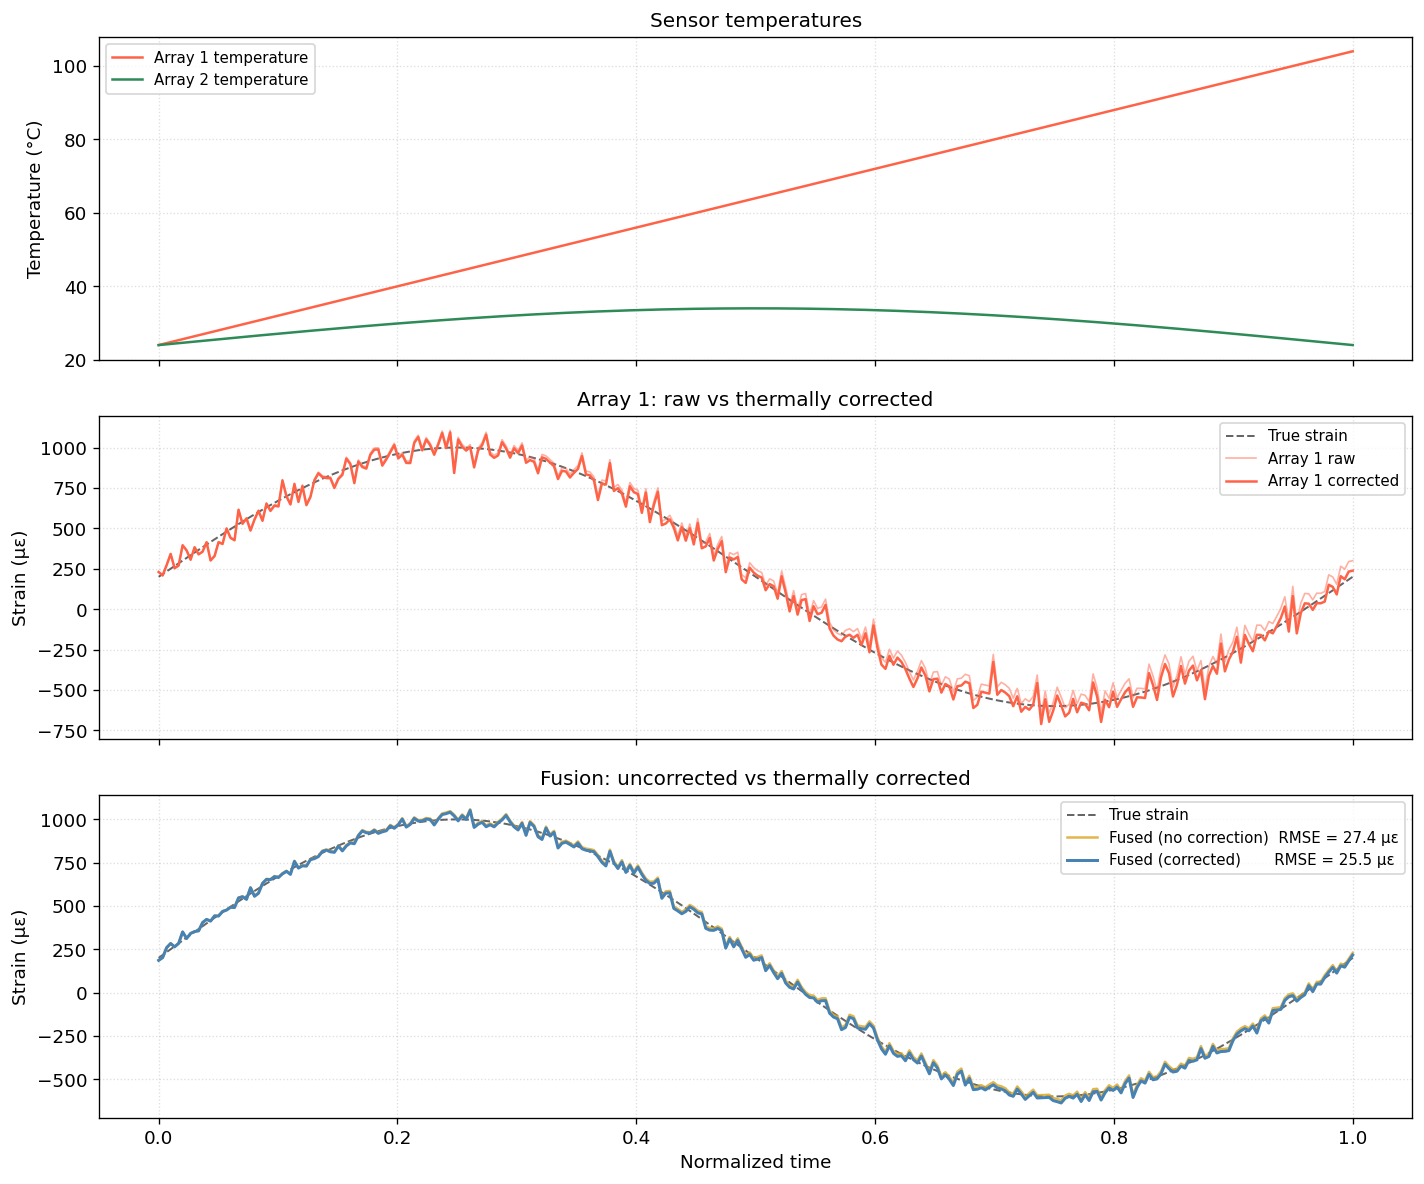

Fusion RMSE without thermal correction: 27.4 µε
Fusion RMSE with    thermal correction: 25.5 µε
Improvement: 7.0%


In [5]:
# --- Thermally-corrected sensor fusion ---
np.random.seed(42)
n = 300

# Gage and reference properties (Constantan on steel)
T_ref    = 24.0
GF_0     = 2.07
TCS      = -1.0e-4    # /°C  — gage-factor temperature coefficient
TO_coeff = 0.8        # µε/°C — residual thermal output for an STC gage on steel

# True mechanical strain over time (one loading cycle)
t = np.linspace(0, 1, n)
eps_true = 800 * np.sin(2 * np.pi * t) + 200   # µε

# Temperature environments — Array 1 near heat source, Array 2 ambient
T1 = 24 + 80 * t                  # °C: heats from 24 -> 104°C over the test
T2 = 24 + 10 * np.sin(np.pi * t)  # °C: mild ambient variation

def gf(T):
    """Gage factor at temperature T: GF_0 * (1 + TCS * (T - T_ref))."""
    return GF_0 * (1 + TCS * (T - T_ref))

def thermal_output(T):
    """Residual apparent strain (µε) of the STC gage at temperature T."""
    return TO_coeff * (T - T_ref)

# Raw indicated strain: mechanical truth scaled by GF drift, plus thermal output, plus noise
noise_sigma1, noise_sigma2 = 60, 30   # µε random noise

eps_raw1 = (eps_true * gf(T1) / GF_0
            + thermal_output(T1)
            + np.random.normal(0, noise_sigma1, n))

eps_raw2 = (eps_true * gf(T2) / GF_0
            + thermal_output(T2)
            + np.random.normal(0, noise_sigma2, n))

def correct(eps_raw, T):
    """Invert the thermal model: remove thermal output, then undo GF drift.

    Subtracts the apparent strain and multiplies by GF_0/gf(T), recovering the
    mechanical strain (plus scaled noise) that produced the raw reading.
    """
    eps_to_removed   = eps_raw - thermal_output(T)
    eps_gf_corrected = eps_to_removed * GF_0 / gf(T)
    return eps_gf_corrected

eps_c1 = correct(eps_raw1, T1)
eps_c2 = correct(eps_raw2, T2)

# Optimal fusion on raw vs. corrected signals (weights from measurement noise)
w1, w2 = inverse_variance_weights([noise_sigma1**2, noise_sigma2**2])

eps_fused_raw = w1 * eps_raw1 + w2 * eps_raw2       # fused without correction
eps_fused_cor = w1 * eps_c1   + w2 * eps_c2          # fused after correction

rmse_raw = np.sqrt(np.mean((eps_fused_raw - eps_true)**2))
rmse_cor = np.sqrt(np.mean((eps_fused_cor - eps_true)**2))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Temperature profiles
axes[0].plot(t, T1, color='tomato',   lw=1.5, label='Array 1 temperature')
axes[0].plot(t, T2, color='seagreen', lw=1.5, label='Array 2 temperature')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Sensor temperatures')
axes[0].legend(fontsize=9); axes[0].grid(True, linestyle=':', alpha=0.4)

# Raw vs corrected for Array 1 (worst-affected)
axes[1].plot(t, eps_true,  'k--', lw=1.2, alpha=0.6, label='True strain')
axes[1].plot(t, eps_raw1,  color='tomato',   lw=1.0, alpha=0.5, label='Array 1 raw')
axes[1].plot(t, eps_c1,    color='tomato',   lw=1.5, label='Array 1 corrected')
axes[1].set_ylabel('Strain (µε)')
axes[1].set_title('Array 1: raw vs thermally corrected')
axes[1].legend(fontsize=9); axes[1].grid(True, linestyle=':', alpha=0.4)

# Fused: with and without correction
axes[2].plot(t, eps_true,      'k--', lw=1.2, alpha=0.6, label='True strain')
axes[2].plot(t, eps_fused_raw, color='goldenrod', lw=1.5, alpha=0.8,
             label=f'Fused (no correction)  RMSE = {rmse_raw:.1f} µε')
axes[2].plot(t, eps_fused_cor, color='steelblue', lw=1.8,
             label=f'Fused (corrected)       RMSE = {rmse_cor:.1f} µε')
axes[2].set_xlabel('Normalized time')
axes[2].set_ylabel('Strain (µε)')
axes[2].set_title('Fusion: uncorrected vs thermally corrected')
axes[2].legend(fontsize=9); axes[2].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig58_nb1_fusion_thermal_corrected.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Fusion RMSE without thermal correction: {rmse_raw:.1f} µε")
print(f"Fusion RMSE with    thermal correction: {rmse_cor:.1f} µε")
print(f"Improvement: {100*(rmse_raw - rmse_cor)/rmse_raw:.1f}%")

---
## Where to take this next

The three demonstrations above are deliberately minimal — analytic fusion, a thermal-output model, and a hard-coded thermal correction. Each is a starting point you can build on:

1. **Replace the two-sensor average with a Kalman filter.** Section 1 fuses two static estimates of one load. Give the load its own dynamics (a random-walk or constant-velocity state model) and fuse a *time series* of noisy readings recursively; compare the filter's steady-state variance to the static reciprocal-sum result of Eq. 58.6.
2. **Add correlated noise and watch fusion fail.** The minimum-variance rule assumes independent sensors. Draw the two arrays' noise from a bivariate normal with a nonzero correlation ρ (shared excitation drift, common interference) and plot the *true* fused variance against the variance you would have predicted assuming independence — the correlated-uncertainty trap of Chapter 48.
3. **Learn the thermal correction instead of hard-coding it.** Feed temperature in as an explicit feature and fit a small regressor (a linear model, or gradient-boosted trees, with a proper train/test split and a fixed `random_state`) to predict mechanical strain from raw output and temperature. Compare its RMSE to the analytic correction in Section 4 — this is the data-driven version of "carry the environmental state as an explicit input."